Importing the Dependencies

In [80]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn import svm #support vector machine
from sklearn.metrics import accuracy_score

TASK 1: DATA COLLECTION AND ANALYSIS

In [81]:
# IMPORT THE DATASET AND PRINT THE FIRST 5 ROWS
diabetes_dataset = pd.read_csv('diabetes.csv')
diabetes_dataset.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [82]:
# INFORMATION ABOUT THE DATASET(ROWS, COLUMNS, NULL VALUES)
diabetes_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [61]:
# DESCRIPTION OF THE DATASET
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [62]:
#PRINT THE NUMBER OF DIABETIC AND NON-DIABETIC PEOPLE
diabetes_dataset['Outcome'].value_counts()# 0 = non-diabetic, 1 = diabetic

Outcome
0    500
1    268
Name: count, dtype: int64

In [63]:
#PRINT AVERAGE_VALUE OF ALL COLUMNS GROUPED BY THE OUTCOME
diabetes_dataset.groupby('Outcome').mean() # 0 = non-diabetic, 1 = diabetic

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [64]:
# SEPARATING THE DATA AND LABELS AND PRINT EACH OF THEM
X = diabetes_dataset.drop(columns= 'Outcome', axis= 1)
Y = diabetes_dataset['Outcome']

In [65]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [66]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


TASK 2: DATA STANDARTIZATION

In [67]:
#standardize and fit the data 
scaler = StandardScaler()

In [68]:
scaler.fit(X)

StandardScaler()

In [69]:
standadized_data = scaler.transform(X)

In [70]:
print (standadized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [71]:
# PRINT THE X_DATA AND Y_LABELS
X = standadized_data
Y = diabetes_dataset['Outcome']
print(X)
print (Y)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


TASK 3: MACHINE LEARNING (TRAINING A MODEL) 

In [72]:
#SPLIT THE DATA INTO TRAINING DATA AND TESTING DATA
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify= Y, random_state = 2) #stratify is used to split the data in a balanced way,0.2 means 20% of the data is used for testing
                                                                                                         # and 80% for training and random_state is used to split the data in the same way every time we run the code

In [73]:
#PRINT THE SHAPE OF THE X_DATA
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


In [74]:
# USING SUPPORT VECTOR MACHINE TO TRAIN THE MODEL
classifer = svm.SVC(kernel = 'linear')
classifer.fit(X_train, Y_train)


SVC(kernel='linear')

In [75]:
#PRINT THE ACCURACY SCORE OF THE TRAINING DATA AND TEST DATA
X_train_prediction = classifer.predict(X_train)
trainig_data_accuracy = accuracy_score(X_train_prediction, Y_train)
X_test_prediction = classifer.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the training data : ', trainig_data_accuracy)
print('Accuracy score of the testing data : ', test_data_accuracy)


Accuracy score of the training data :  0.7866449511400652
Accuracy score of the testing data :  0.7727272727272727


OVERTRAINING OR OVERFITTING ?
RESPONSE: The model has not overtrained, because in tha case the training data accuracy will be very high and the test data accuracy will be very low. That means that we have an overfitting in this case. 

TASK 4: MODEL PREDICTION

In [76]:
#PREDICT THE OUTPUT OF THE MODEL ABOUT THE FOLLOWING ONE ROW OF DATA
input_data = (4,110,92,0,0,37.6,0.191,30)
input_data_as_numpy_array = np.asarray(input_data) #convert the input data into numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1) #reshape the array as we are predicting the output of only one row
standadized_input_data = scaler.transform(input_data_reshaped) #standadize the input data
print(standadized_input_data)
 
prediction = classifer.predict(standadized_input_data)
print(prediction)

if(prediction[0] == 0):
    print('The person is not diabetic')
else:
    print ('The Person is diabetic')


[[ 0.04601433 -0.34096773  1.18359575 -1.28821221 -0.69289057  0.71168975
  -0.84827977 -0.27575966]]
[0]
The person is not diabetic


c:\Users\steve\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [77]:
#PREDICT ALSO FOR THE FOLLOWING ROW OF DATA
input_data = (5,166,72,19,175,25.8,0.587,51)
input_data_as_numpy_array = np.asarray(input_data) #convert the input data into numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1) #reshape the array as we are predicting the output of only one row
standadized_input_data = scaler.transform(input_data_reshaped) #standadize the input data
print(standadized_input_data)
 
prediction = classifer.predict(standadized_input_data)
print(prediction)

if(prediction[0] == 0):
    print('The person is not diabetic')
else:
    print ('The Person is diabetic')

[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
The Person is diabetic


c:\Users\steve\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


TASK 5: DATA VISUALIZATION

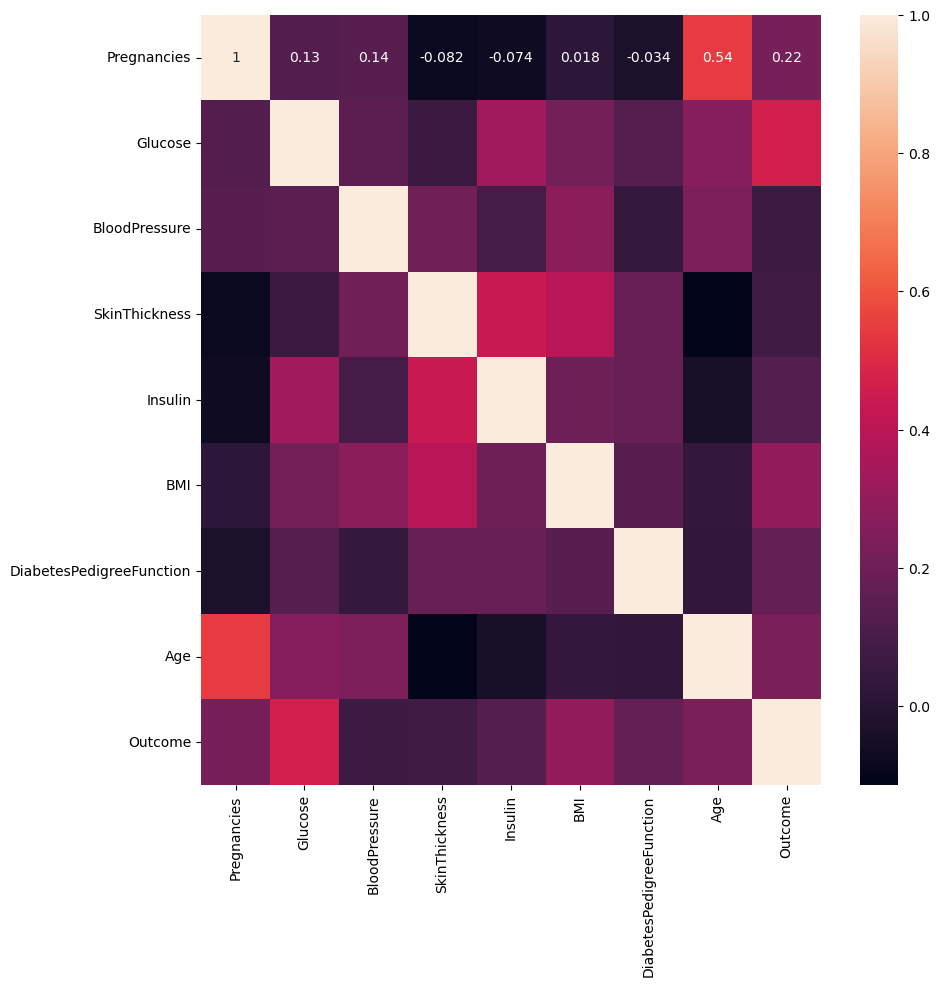

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# PLOT THE HEATMAP OF THE CORRELATION MATRIX WITH FIGURE SIZE 10*10

correlation_matrix = diabetes_dataset.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix, annot = True)
plt.show()



<Axes: xlabel='Glucose', ylabel='Insulin'>

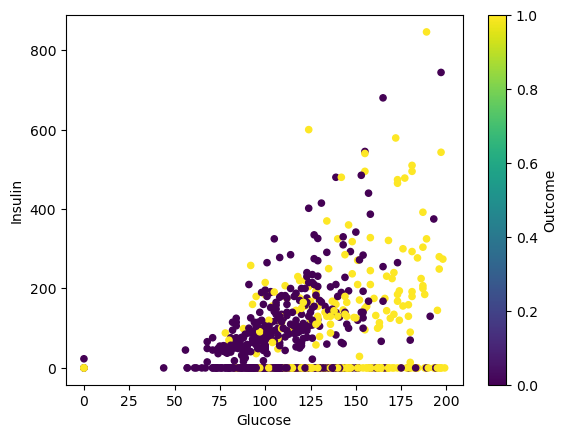

In [79]:
#BONUS: PLOTTING A RANDOM SCATTER PLOT OF THE DATASET
diabetes_dataset.plot.scatter(x='Glucose', y = 'Insulin', c = 'Outcome', colormap = 'viridis')

<Axes: xlabel='Glucose', ylabel='Insulin'>

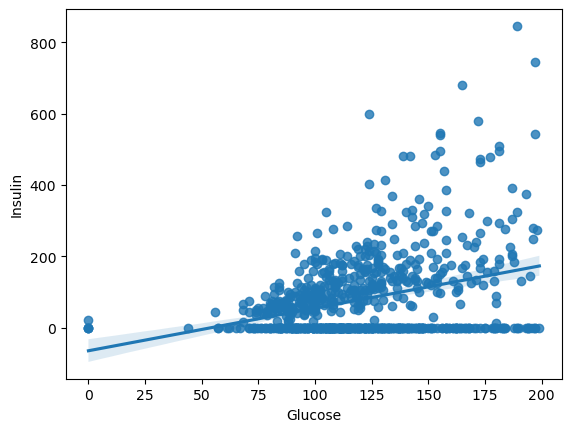

In [85]:
# BONUS: PLOTTING A RANDOM REGRESSION PLOT OF THE DATASET
sns.regplot(x = 'Glucose', y = 'Insulin', data = diabetes_dataset) 